C:\Users\Dell\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - accuracy: 0.6986 - loss: 0.8395 - val_accuracy: 0.7937 - val_loss: 0.5924
Epoch 2/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.8069 - loss: 0.5101 - val_accuracy: 0.8106 - val_loss: 0.5143
Epoch 3/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.8420 - loss: 0.4268 - val_accuracy: 0.8481 - val_loss: 0.4510
Epoch 4/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.8598 - loss: 0.3862 - val_accuracy: 0.8587 - val_loss: 0.4072
Epoch 5/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.8750 - loss: 0.3380 - val_accuracy: 0.8675 - val_loss: 0.3731
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8565 - loss: 0.3947
Test Loss: 0.394661009311676
Test Accuracy: 0.8565000295639038
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step
Predicted: sneaker


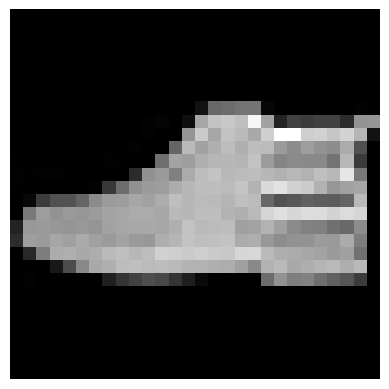

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
Predicted: pullover


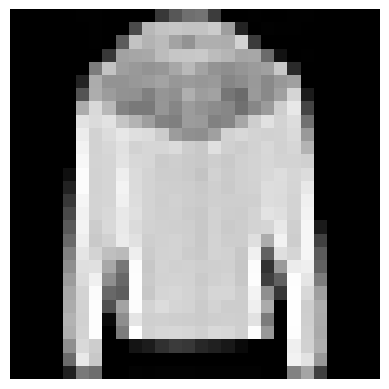

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
Predicted: sandal


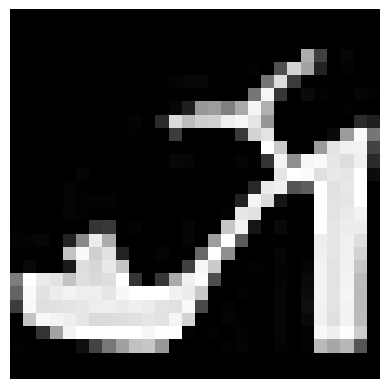

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
Predicted: coat


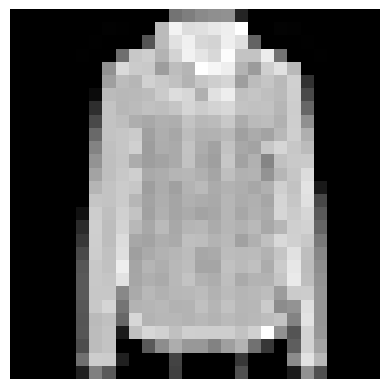

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
Predicted: shirt


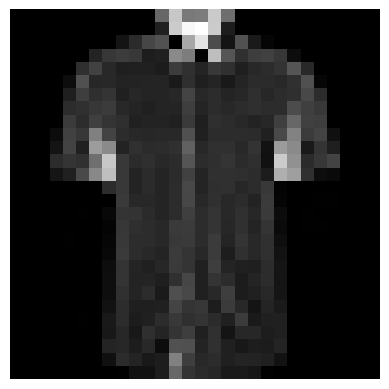

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
Predicted: pullover


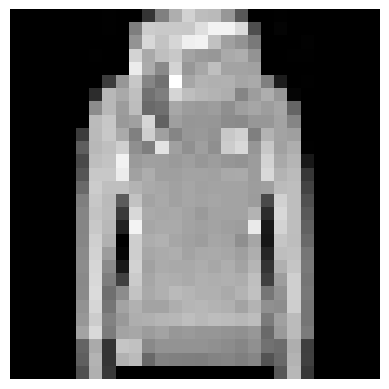

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
Predicted: shirt


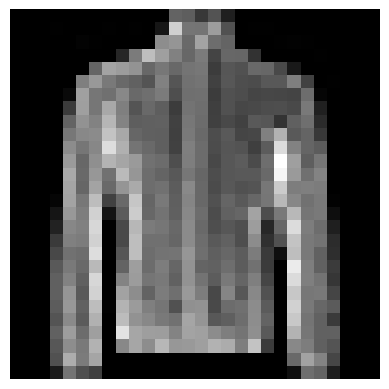

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
Predicted: ankle_boot


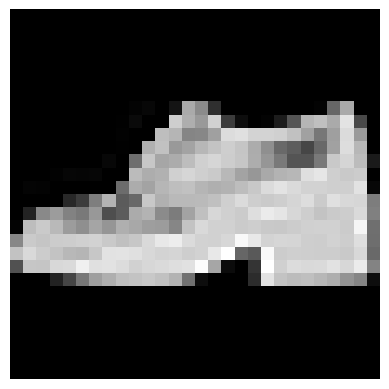

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
Predicted: dress


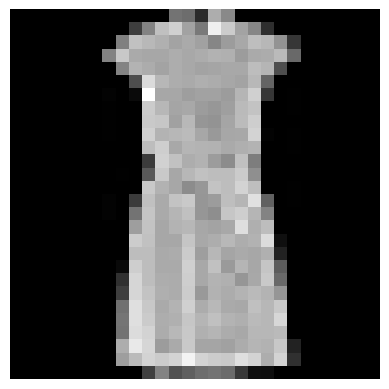

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
Predicted: sneaker


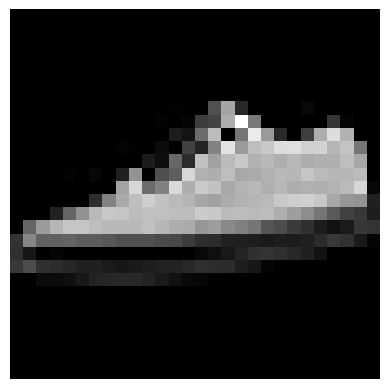

In [3]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Flatten, Dense

# Step 2: Load CSV Dataset
# First column = label
# Remaining 784 columns = pixel values

data = pd.read_csv("fashion-mnist_test.csv")

# Step 3: Separate Features and Labels
X = data.iloc[:, 1:].values
y = data.iloc[:, 0].values

# Step 4: Normalize and Reshape
X = X.astype('float32') / 255.0
X = X.reshape(-1, 28, 28, 1)

# Step 5: Train-Test Split
train_x, test_x, train_y, test_y = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 6: Build CNN Model
model = Sequential()

model.add(Conv2D(
    32,
    kernel_size=(3,3),
    activation='relu',
    input_shape=(28,28,1)
))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(
    64,
    kernel_size=(3,3),
    activation='relu'
))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dense(10, activation='softmax'))

# Step 7: Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Step 8: Model Summary
model.summary()

# Step 9: Train Model
model.fit(
    train_x,
    train_y,
    epochs=5,
    validation_split=0.2
)

# Step 10: Evaluate Model
loss, acc = model.evaluate(test_x, test_y)

print("Test Loss:", loss)
print("Test Accuracy:", acc)

# Step 11: Class Labels
label_names = [
    't_shirt',
    'trouser',
    'pullover',
    'dress',
    'coat',
    'sandal',
    'shirt',
    'sneaker',
    'bag',
    'ankle_boot'
]

# Step 12: Prediction Function
def predict(id_):

    prediction = model.predict(test_x[id_:id_+1])

    predicted_label = label_names[np.argmax(prediction)]

    print("Predicted:", predicted_label)

    plt.imshow(test_x[id_].reshape(28,28), cmap='gray')
    plt.axis('off')
    plt.show()

# Step 13: Test Predictions
for i in range(10, 20):
    predict(i)